In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes_data = load_diabetes(as_frame=True)
df = diabetes_data.frame

print(df.head())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


**Bloque 1**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

x = df[['bmi']]
y= df['target']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

y_pred = linear_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")


Mean Squared Error: 4061.8259284949268


**Bloque 2**

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

y_bin = (df['target'] > 140).astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y_bin, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(x_train, y_train)

y_pred = log_model.predict(x_test)

print('Precision: ', log_model.score(x_test, y_test))

Precision:  0.7078651685393258


**BLoque 3**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier()

tree_model.fit(x_train, y_train)

y_pred = tree_model.predict(x_test)

print('Precision del arbol de decision', accuracy_score(y_test, y_pred) )

Precision del arbol de decision 0.7191011235955056


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print('Precision del Random Forest', accuracy_score(y_test, y_pred_rf))


Precision del Random Forest 0.7078651685393258


**BLoque 4**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.7027027027027027
Recall: 0.65
F1 Score: 0.6753246753246753


**Bloque 5**

In [ ]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(rf_model, x, y_bin, cv=5)

print(f"Puntaje de validación cruzada: {cv_score}")
print(f"Promedio de validación cruzada: {cv_score.mean()}")

Puntaje de validación cruzada: [0.56179775 0.64044944 0.69318182 0.625      0.60227273]
Promedio de validación cruzada: 0.6245403472931563


**Bloque 6**

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

data = pd.Series([100, 102, 105, 107, 110, 111, 115, 117, 120, 125])

arima_model = ARIMA(data, order=(1, 1, 1))
arima_result = arima_model.fit()

predisiones = arima_result.forecast(steps = 5)

print(predisiones)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


10    128.012789
11    131.012069
12    133.997901
13    136.970345
14    139.929461
Name: predicted_mean, dtype: float64


**Bloque 7**

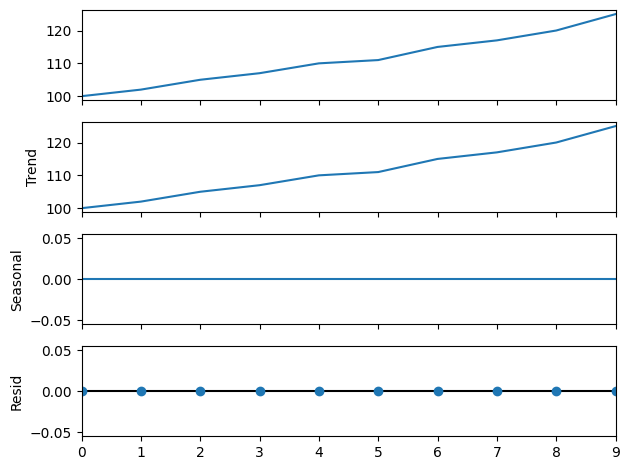

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(data, model='additive', period=1)

result.plot()
plt.show()
